In [ ]:
import pickle
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
def compute_snr(clean, noisy):
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean((clean - noisy) ** 2)
    return 10 * np.log10(signal_power / noise_power)

with open('../../ETL/data/pickles/processed.pkl', 'rb') as file:
	data = pickle.load(file)
# with open('../../ETL/data/pickles/patches.pkl', 'rb') as file:
# 	patches = pickle.load(file)

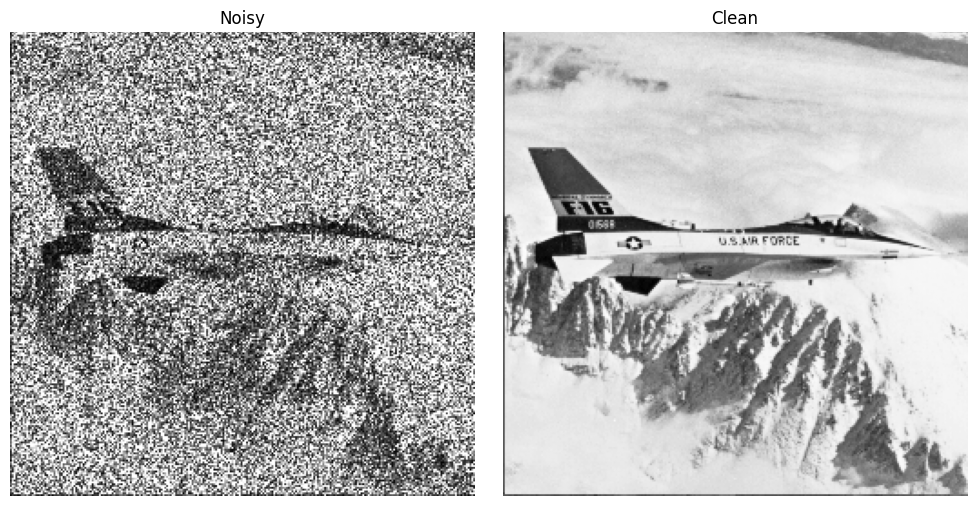

Image shape: (256, 256)
Noisy Image shape: (256, 256)
Image mean: 0.69896454
Noisy Image mean: 0.5802618
Image std: 0.18350331
Noisy Image std: 0.31959474
Image min-max: (np.float32(0.0627451), np.float32(0.9019608))
Noisy Image min-max: (np.float32(0.0), np.float32(1.0))


In [7]:
i = 7
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]

# let's visualise the images with cv2, the images are in numpy array format np.float32 between 0 and 1
plt.figure(figsize=(10,5))
# Noisy
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
# Clean
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", img.shape)
print("Noisy Image shape:", noisy_img.shape)
print("Image mean:", np.mean(img))
print("Noisy Image mean:", np.mean(noisy_img))
print("Image std:", np.std(img))
print("Noisy Image std:", np.std(noisy_img))
print("Image min-max:", (np.min(img), np.max(img)))
print("Noisy Image min-max:", (np.min(noisy_img), np.max(noisy_img)))

In [30]:
# conversion → uint8
i = 7
metrics = {}
for i in range(len(data['bsd68']['clean'])):
    img = data['bsd68']['clean'][i]
    noisy_img = data['bsd68']['noisy'][i]
    noisy_8 = (noisy_img * 255).astype(np.uint8)

    # filtre médian (k=3,5,7…)
    k = 7
    metrics[i] = {}
    for k in range(3, 18, 2):
        denoised_8 = cv2.medianBlur(noisy_8, k)
        denoised_8_1 = cv2.medianBlur(denoised_8, k)

        # retour float32 [0,1]
        denoised = denoised_8.astype(np.float32) / 255.0
        denoised_1 = denoised_8_1.astype(np.float32) / 255.0

        psnr_value = psnr(img, noisy_img, data_range=1.0)
        ssim_value = ssim(img, noisy_img, data_range=1.0)
        snr_value = compute_snr(img, noisy_img)

        psnr_denoised = psnr(img, denoised, data_range=1.0)
        ssim_denoised = ssim(img, denoised, data_range=1.0)
        snr_denoised = compute_snr(img, denoised)

        metrics[i][k] = {
            'PSNR_base': 55,
            'SSIM_base': 1,
            'SNR_base': 55,
            'PSNR_noisy': psnr_value,
            'SSIM_noisy': ssim_value,
            'SNR_noisy': snr_value, 
            'PSNR_denoised': psnr_denoised,
            'SSIM_denoised': ssim_denoised,
            'SNR_denoised': snr_denoised
        }
    


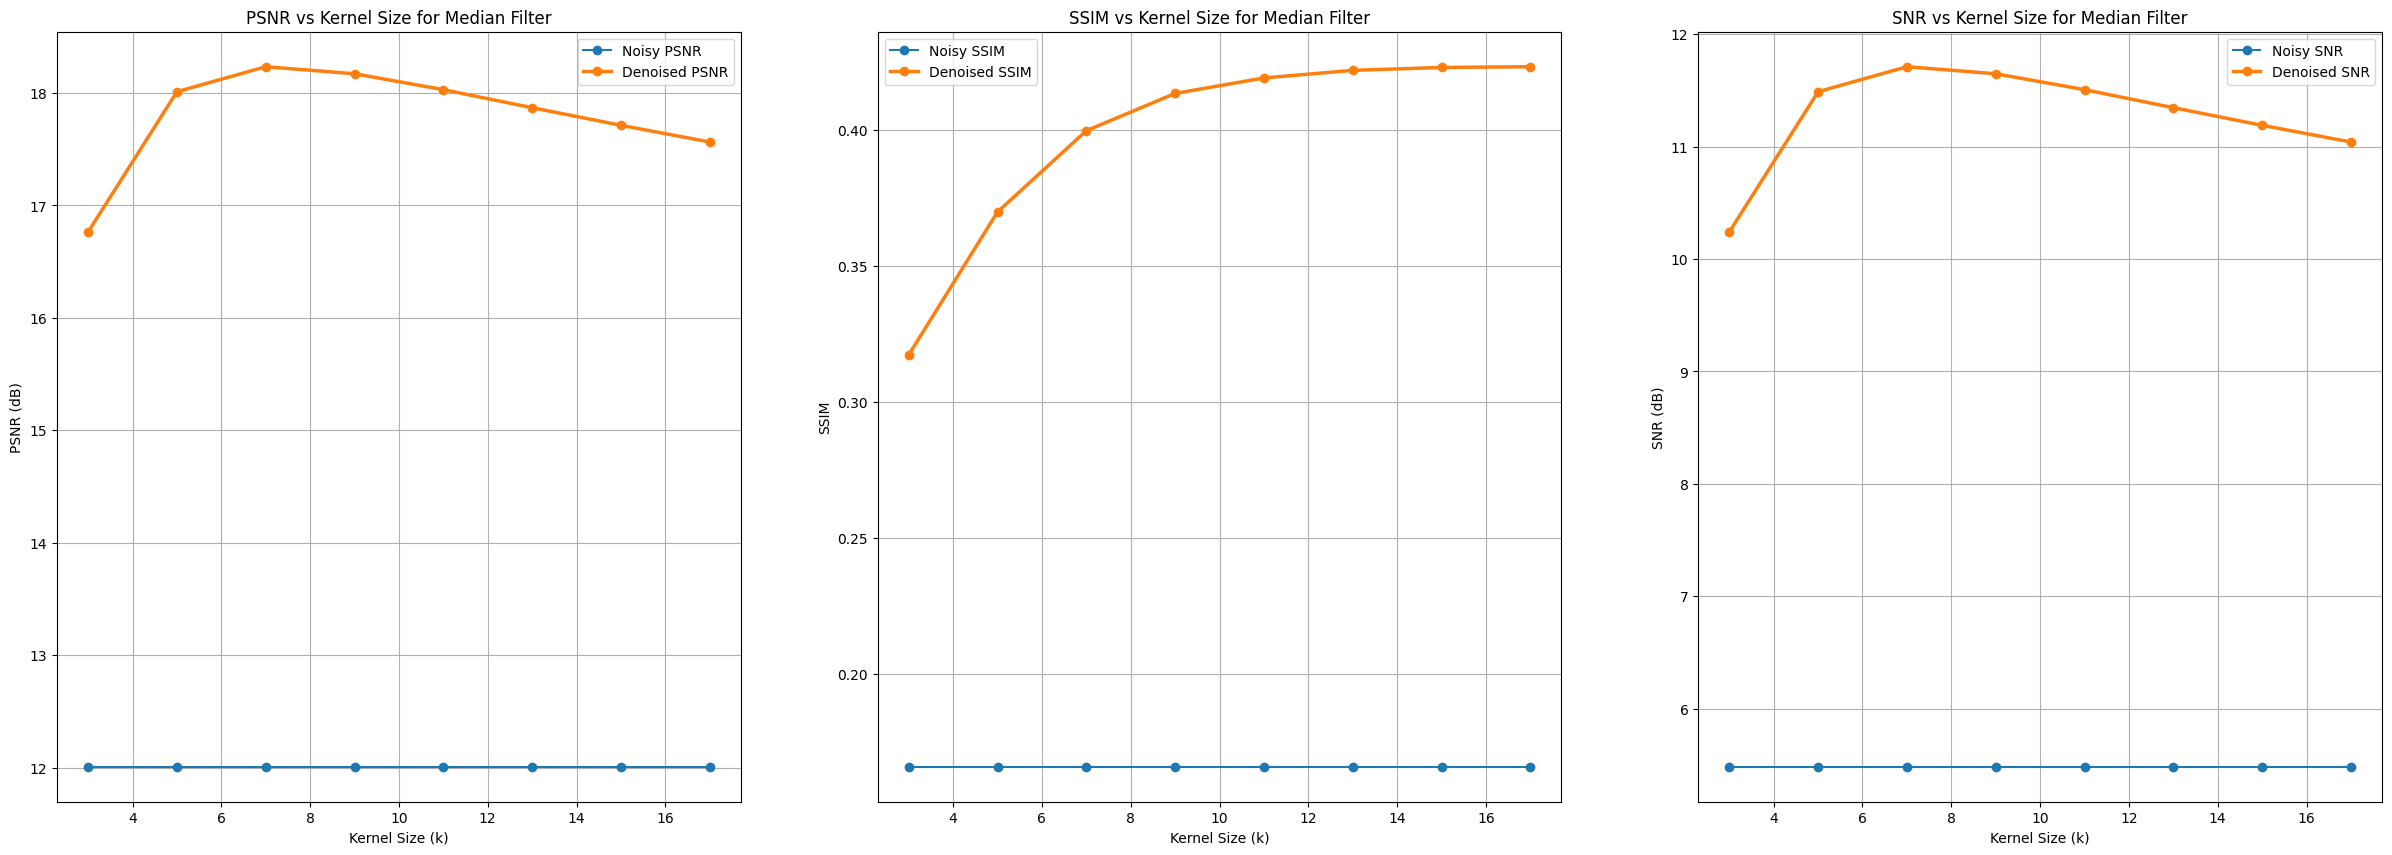

In [32]:
new_metrics = {}
range_n = len(data['bsd68']['clean'])
for i in range(3, 18, 2):
    new_metrics[i] = {
        'PSNR_base': {
            'mean': np.mean([metrics[j][i]['PSNR_base'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['PSNR_base'] for j in range(range_n)])
        },
        'SSIM_base': {
            'mean': np.mean([metrics[j][i]['SSIM_base'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SSIM_base'] for j in range(range_n)])
        },
        'SNR_base': {
            'mean': np.mean([metrics[j][i]['SNR_base'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SNR_base'] for j in range(range_n)])
        },
        'PSNR_noisy': {
            'mean': np.mean([metrics[j][i]['PSNR_noisy'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['PSNR_noisy'] for j in range(range_n)])
        },
        'SSIM_noisy': {
            'mean': np.mean([metrics[j][i]['SSIM_noisy'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SSIM_noisy'] for j in range(range_n)])
        },
        'SNR_noisy': {
            'mean': np.mean([metrics[j][i]['SNR_noisy'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SNR_noisy'] for j in range(range_n)])
        },
        'PSNR_denoised': {
            'mean': np.mean([metrics[j][i]['PSNR_denoised'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['PSNR_denoised'] for j in range(range_n)])
        },
        'SSIM_denoised': {
            'mean': np.mean([metrics[j][i]['SSIM_denoised'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SSIM_denoised'] for j in range(range_n)])
        },
        'SNR_denoised': {
            'mean': np.mean([metrics[j][i]['SNR_denoised'] for j in range(range_n)]),
            'std': np.std([metrics[j][i]['SNR_denoised'] for j in range(range_n)])
        }
    }

ks = list(new_metrics.keys())
psnr_base = [new_metrics[k]['PSNR_base']['mean'] for k in ks]
psnr_noisy = [new_metrics[k]['PSNR_noisy']['mean'] for k in ks]
psnr_denoised = [new_metrics[k]['PSNR_denoised']['mean'] for k in ks]

ssim_base = [new_metrics[k]['SSIM_base']['mean'] for k in ks]
ssim_noisy = [new_metrics[k]['SSIM_noisy']['mean'] for k in ks]
ssim_denoised = [new_metrics[k]['SSIM_denoised']['mean'] for k in ks]

snr_base = [new_metrics[k]['SNR_base']['mean'] for k in ks]
snr_noisy = [new_metrics[k]['SNR_noisy']['mean'] for k in ks]
snr_denoised = [new_metrics[k]['SNR_denoised']['mean'] for k in ks]

plt.figure(figsize=(30, 10))
# PSNR
plt.subplot(1, 3, 1)
# plt.plot(ks, psnr_base, label='Base PSNR : +inf', marker='o', linewidth=1)
plt.plot(ks, psnr_noisy, label='Noisy PSNR', marker='o', linewidth=1.5)
plt.plot(ks, psnr_denoised, label='Denoised PSNR', marker='o', linewidth=2.5) 
plt.xlabel('Kernel Size (k)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Kernel Size for Median Filter')
plt.legend()
plt.grid()
# SSIM
plt.subplot(1, 3, 2)
# # plt.plot(ks, ssim_base, label='Base SSIM : 1', marker='o', linewidth=1)
plt.plot(ks, ssim_noisy, label='Noisy SSIM', marker='o', linewidth=1.5)
plt.plot(ks, ssim_denoised, label='Denoised SSIM', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SSIM')
plt.title('SSIM vs Kernel Size for Median Filter')
plt.legend()
plt.grid()
# SNR
plt.subplot(1, 3, 3)
# # plt.plot(ks, snr_base, label='Base SNR : +inf', marker='o', linewidth=1)
plt.plot(ks, snr_noisy, label='Noisy SNR', marker='o', linewidth=1.5)
plt.plot(ks, snr_denoised, label='Denoised SNR', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs Kernel Size for Median Filter')
plt.legend()
plt.grid()

In [ ]:

ks = list(metrics.keys())
psnr_base = [max([metrics[k]['PSNR_noisy'] for k in ks])*2 for k in ks]
ssim_base = [1 for k in ks]
snr_base = [max([metrics[k]['SNR_noisy'] for k in ks])*2 for k in ks]

psnr_noisy = [metrics[k]['PSNR_noisy'] for k in ks]
ssim_noisy = [metrics[k]['SSIM_noisy'] for k in ks]
snr_noisy = [metrics[k]['SNR_noisy'] for k in ks]

psnr_denoised = [metrics[k]['PSNR_denoised'] for k in ks]
ssim_denoised = [metrics[k]['SSIM_denoised'] for k in ks]
snr_denoised = [metrics[k]['SNR_denoised'] for k in ks]

plt.figure(figsize=(30,10))
# PSNR
plt.subplot(1, 3, 1)
plt.plot(ks, psnr_base, label='Base PSNR : +inf', marker='o', linewidth=1)
plt.plot(ks, psnr_noisy, label='Noisy PSNR', marker='o', linewidth=1.5)
plt.plot(ks, psnr_denoised, label='Denoised PSNR', marker='o', linewidth=2.5) 
plt.xlabel('Kernel Size (k)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Kernel Size')
plt.legend()

# SSIM
plt.subplot(1, 3, 2)
plt.plot(ks, ssim_base, label='Base SSIM : 1', marker='o', linewidth=1)
plt.plot(ks, ssim_noisy, label='Noisy SSIM', marker='o', linewidth=1.5)
plt.plot(ks, ssim_denoised, label='Denoised SSIM', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SSIM')
plt.title('SSIM vs Kernel Size')
plt.legend()

# SNR
plt.subplot(1, 3, 3)
plt.plot(ks, snr_base, label='Base SNR : +inf', marker='o', linewidth=1)
plt.plot(ks, snr_noisy, label='Noisy SNR', marker='o', linewidth=1.5)
plt.plot(ks, snr_denoised, label='Denoised SNR', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs Kernel Size')
plt.legend()

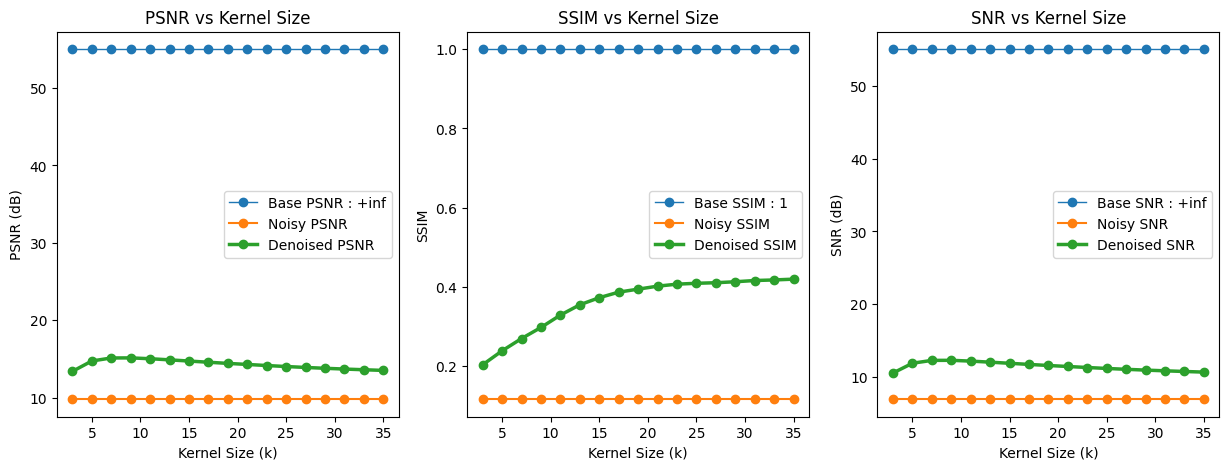

In [18]:
# conversion → uint8
i = 7
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]
noisy_8 = (noisy_img * 255).astype(np.uint8)

# filtre médian (k=3,5,7…)
k = 7
metrics = {}
for k in range(3, 36, 2):
    denoised_8 = cv2.medianBlur(noisy_8, k)
    denoised_8_1 = cv2.medianBlur(denoised_8, k)

    # retour float32 [0,1]
    denoised = denoised_8.astype(np.float32) / 255.0
    denoised_1 = denoised_8_1.astype(np.float32) / 255.0

    psnr_value = psnr(img, noisy_img, data_range=1.0)
    ssim_value = ssim(img, noisy_img, data_range=1.0)
    snr_value = compute_snr(img, noisy_img)

    psnr_denoised = psnr(img, denoised, data_range=1.0)
    ssim_denoised = ssim(img, denoised, data_range=1.0)
    snr_denoised = compute_snr(img, denoised)

    metrics[k] = {
        'PSNR_base': 55,
        'SSIM_base': 1,
        'SNR_base': 55,
        'PSNR_noisy': psnr_value,
        'SSIM_noisy': ssim_value,
        'SNR_noisy': snr_value, 
        'PSNR_denoised': psnr_denoised,
        'SSIM_denoised': ssim_denoised,
        'SNR_denoised': snr_denoised
    }
    # plt.figure(figsize=(15,5))

    # # Noisy
    # plt.subplot(1, 4, 1)
    # plt.imshow(noisy_img, cmap='gray')
    # plt.title("Noisy")
    # plt.axis("off")

    # # Original (clean)
    # plt.subplot(1, 4, 2)
    # plt.imshow(img, cmap='gray')
    # plt.title("Clean")
    # plt.axis("off")

    # # Denoised (median)
    # plt.subplot(1, 4, 3)
    # plt.imshow(denoised, cmap='gray')
    # plt.title("Median Denoised")
    # plt.axis("off")

    # # Denoised (median, second pass)
    # plt.subplot(1, 4, 4)
    # plt.imshow(denoised_1, cmap='gray')
    # plt.title("Median Denoised 2x")
    # plt.axis("off")

    # plt.tight_layout()
    # plt.show()

#  plot metrics

ks = list(metrics.keys())
psnr_base = [metrics[k]['PSNR_base'] for k in ks]
ssim_base = [metrics[k]['SSIM_base'] for k in ks]
snr_base = [metrics[k]['SNR_base'] for k in ks]
psnr_noisy = [metrics[k]['PSNR_noisy'] for k in ks]
psnr_denoised = [metrics[k]['PSNR_denoised'] for k in ks]
ssim_noisy = [metrics[k]['SSIM_noisy'] for k in ks]
ssim_denoised = [metrics[k]['SSIM_denoised'] for k in ks]
snr_noisy = [metrics[k]['SNR_noisy'] for k in ks]
snr_denoised = [metrics[k]['SNR_denoised'] for k in ks]

plt.figure(figsize=(15,5))
# PSNR
plt.subplot(1, 3, 1)
plt.plot(ks, psnr_base, label='Base PSNR : +inf', marker='o', linewidth=1)
plt.plot(ks, psnr_noisy, label='Noisy PSNR', marker='o', linewidth=1.5)
plt.plot(ks, psnr_denoised, label='Denoised PSNR', marker='o', linewidth=2.5) 
plt.xlabel('Kernel Size (k)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Kernel Size')
plt.legend()

# SSIM
plt.subplot(1, 3, 2)
plt.plot(ks, ssim_base, label='Base SSIM : 1', marker='o', linewidth=1)
plt.plot(ks, ssim_noisy, label='Noisy SSIM', marker='o', linewidth=1.5)
plt.plot(ks, ssim_denoised, label='Denoised SSIM', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SSIM')
plt.title('SSIM vs Kernel Size')
plt.legend()

# SNR
plt.subplot(1, 3, 3)
plt.plot(ks, snr_base, label='Base SNR : +inf', marker='o', linewidth=1)
plt.plot(ks, snr_noisy, label='Noisy SNR', marker='o', linewidth=1.5)
plt.plot(ks, snr_denoised, label='Denoised SNR', marker='o', linewidth=2.5)
plt.xlabel('Kernel Size (k)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs Kernel Size')
plt.legend()

In [15]:
metrics

{3: {'PSNR_base': np.float64(inf),
  'SSIM_base': np.float64(1.0),
  'SNR_base': np.float32(inf),
  'PSNR_noisy': np.float64(9.811238218051832),
  'SSIM_noisy': np.float64(0.11677575689688154),
  'SNR_noisy': np.float32(6.989814),
  'PSNR_denoised': np.float64(13.407880424947102),
  'SSIM_denoised': np.float64(0.20384988901331724),
  'SNR_denoised': np.float32(10.586456)},
 5: {'PSNR_base': np.float64(inf),
  'SSIM_base': np.float64(1.0),
  'SNR_base': np.float32(inf),
  'PSNR_noisy': np.float64(9.811238218051832),
  'SSIM_noisy': np.float64(0.11677575689688154),
  'SNR_noisy': np.float32(6.989814),
  'PSNR_denoised': np.float64(14.749026356468352),
  'SSIM_denoised': np.float64(0.2390316431951202),
  'SNR_denoised': np.float32(11.927603)},
 7: {'PSNR_base': np.float64(inf),
  'SSIM_base': np.float64(1.0),
  'SNR_base': np.float32(inf),
  'PSNR_noisy': np.float64(9.811238218051832),
  'SSIM_noisy': np.float64(0.11677575689688154),
  'SNR_noisy': np.float32(6.989814),
  'PSNR_denoised':

In [9]:
psnr_value = psnr(img, noisy_img, data_range=1.0)
print("PSNR:", psnr_value, "dB")
ssim_value = ssim(img, noisy_img, data_range=1.0)
print("SSIM:", ssim_value)
snr_value = compute_snr(img, noisy_img)
print("SNR:", snr_value, "dB")

PSNR: 9.811238218051832 dB
SSIM: 0.11677575689688154
SNR: 6.989814 dB


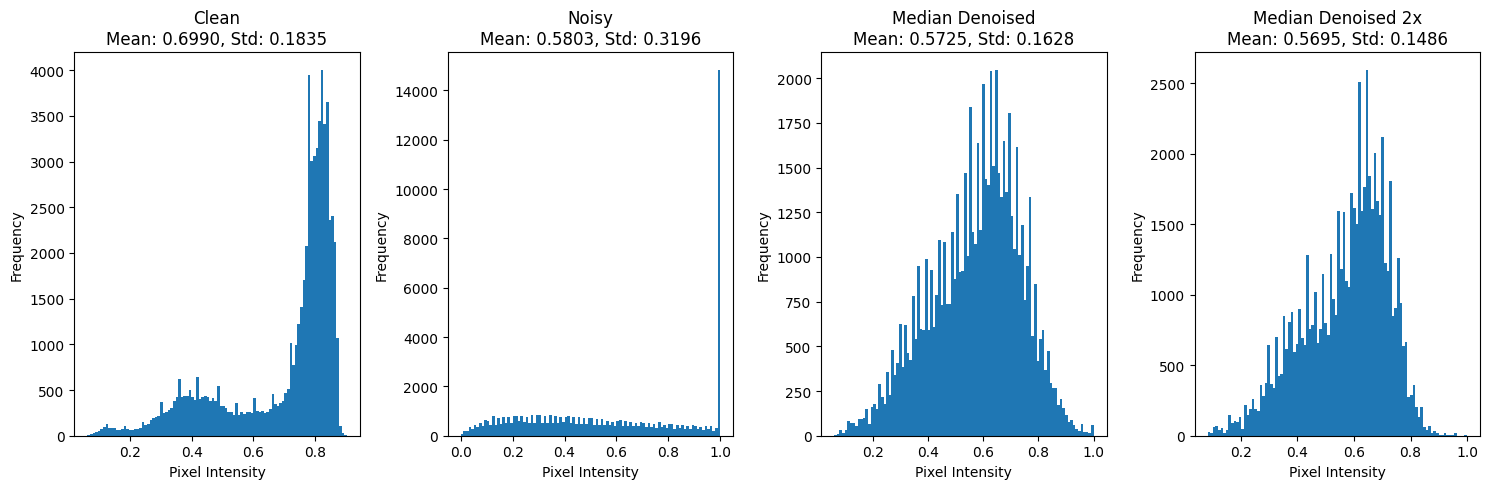

In [6]:
# let's study the mean, std and histogram of original, noisy and denoised images
def plot_image_stats(images, titles):
	plt.figure(figsize=(15,5))
	for i, img in enumerate(images):
		mean = np.mean(img)
		std = np.std(img)
		plt.subplot(1, len(images), i+1)
		plt.hist(img.ravel(), bins=100)
		plt.title(f"{titles[i]}\nMean: {mean:.4f}, Std: {std:.4f}")
		plt.xlabel("Pixel Intensity")
		plt.ylabel("Frequency")
	plt.tight_layout()
	plt.show()
plot_image_stats([img, noisy_img, denoised, denoised_1], ["Clean", "Noisy", "Median Denoised", "Median Denoised 2x"])#!/usr/bin/env python3